In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import time
from PIL import Image
from torchvision import transforms
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from src.data.dataset import FundusDataset
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import WeightedRandomSampler

In [7]:
# 超参数
config = {
    'model_name': 'google/vit-base-patch16-224',  # 预训练ViT模型
    'num_classes': 8,                              # 分类数
    'class_names': ['正常', '糖尿病视网膜病变', '青光眼', '白内障', 
                   '黄斑变性', '高血压视网膜病变', '近视', '其他'],
    'batch_size': 16,                               # 批次大小(16)
    'epochs': 30,                                   # 训练轮数(30)
    'learning_rate': 1e-4,                          # 学习率
     'weight_decay': 1e-4,                           # 权重衰减
     'warmup_steps': 500,                            # 预热步数
     'gradient_accumulation_steps': 2,               # 梯度累积
    'max_grad_norm': 1.0,                           # 梯度裁剪
     'save_dir': 'F:/graduation_project/checkpoints',                   # 模型保存目录
    'log_dir': './logs',                              # TensorBoard日志目录
    'model_path': 'checkpoints/best_model.pth'       #模型位置
 }

# 观察训练结果
# 如果 Epoch 15 后验证 F1 还在上升 → 可以尝试减小 weight_decay
# 如果 Epoch 10 后验证 F1 就开始下降 → 增大 weight_decay

In [8]:
def cpu():
    if torch.cuda.is_available():
        return 'cuda'
    else:
        return 'cpu'

result = cpu()
print(result)
device = torch.device(result)
print(device)

cuda
cuda


In [9]:
train_dir = r'F:\graduation_project\data\processed\Training Images'
test_dir = r'F:\graduation_project\data\processed\Testing Images'
val_dir = r'F:\graduation_project\data\processed\Validation Images'

train_excel_dir = r'F:\graduation_project\data\processed\training annotation (English).xlsx'
test_excel_dir = r'F:\graduation_project\data\processed\off-site test annotation (English).xlsx'
val_excel_dir = r'F:\graduation_project\data\processed\on-site validation annotation (English).xlsx'

# 训练集
train_dataset = FundusDataset(train_dir , train_excel_dir , is_training=True)

# 验证集
val_dataset = FundusDataset(val_dir , val_excel_dir , is_training=False)

# 测试集
test_dataset = FundusDataset(test_dir, test_excel_dir , is_training=False)


In [10]:
# ========== 过采样策略（动态权重计算 - 改进版） ==========
print("收集训练集标签...")
all_train_labels = []
for i in range(len(train_dataset)):
    _, labels, _ = train_dataset[i]
    all_train_labels.append(labels.numpy())
all_train_labels = np.stack(all_train_labels)

print("\n" + "="*60)
print("过采样策略（动态权重 - 激进版）")
print("="*60)

# 统计各类别样本数
class_counts = all_train_labels.sum(axis=0)
print(f"各类别样本数: {class_counts}")

# 计算中位数
median_count = np.median(class_counts)
print(f"中位数样本数: {median_count:.1f}")

# 方法1：平方根权重（让少数类权重更大）
class_weights_for_sampling = np.sqrt(median_count / (class_counts + 1e-6))

# 方法2：对数权重（更温和）
# class_weights_for_sampling = np.log(median_count / (class_counts + 1e-6) + 1)

# 方法3：线性权重（原方法）
# class_weights_for_sampling = median_count / (class_counts + 1e-6)

print(f"各类别采样权重: {[f'{w:.2f}' for w in class_weights_for_sampling]}")

# 计算每个样本的权重（改进版）
sample_weights = []

for i in range(len(train_dataset)):
    _, labels, _ = train_dataset[i]
    
    # 获取当前样本包含的类别索引
    positive_classes = np.where(labels == 1)[0]
    
    if len(positive_classes) > 0:
        # 取所有正类权重的最大值（让模型更关注最难样本）
        weight = max(class_weights_for_sampling[positive_classes])
        # 可选：使用平均值
        # weight = np.mean(class_weights_for_sampling[positive_classes])
    else:
        weight = 1.0
    
    # 提高权重上限，让少数类被更多次采样（从20提高到50）
    weight = np.clip(weight, 1.0, 50.0)
    sample_weights.append(weight)

print(f"权重范围: {min(sample_weights):.2f} - {max(sample_weights):.2f}")
print(f"权重均值: {np.mean(sample_weights):.2f}")

# 打印各类别样本的平均权重（用于验证）
class_avg_weights = []
class_names = ['正常', 'DR', '青光眼', '白内障', '黄斑变性', '高血压', '近视', '其他']
for c in range(8):
    indices = [i for i in range(len(train_dataset)) if train_dataset[i][1][c] == 1]
    if indices:
        avg_w = np.mean([sample_weights[i] for i in indices])
        class_avg_weights.append(avg_w)
    else:
        class_avg_weights.append(0)
print(f"各类别平均权重:")
for i in range(8):
    print(f"  {class_names[i]}: {class_avg_weights[i]:.2f}")

# 创建过采样器（增加采样倍数）
oversampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights) * 3,  # 从2倍增加到3倍
    replacement=True
)

print(f"\n采样信息:")
print(f"  原始样本数: {len(sample_weights)}")
print(f"  采样后样本数: {len(sample_weights) * 3}")
print(f"  采样倍数: 3x")

# 创建 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    sampler=oversampler,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

收集训练集标签...

过采样策略（动态权重 - 激进版）
各类别样本数: [2280. 2256.  430.  424.  328.  206.  348. 1958.]
中位数样本数: 427.0
各类别采样权重: ['0.43', '0.44', '1.00', '1.00', '1.14', '1.44', '1.11', '0.47']
权重范围: 1.00 - 1.44
权重均值: 1.02
各类别平均权重:
  正常: 1.00
  DR: 1.02
  青光眼: 1.03
  白内障: 1.01
  黄斑变性: 1.15
  高血压: 1.44
  近视: 1.11
  其他: 1.01

采样信息:
  原始样本数: 7000
  采样后样本数: 21000
  采样倍数: 3x


In [11]:
# 用已经预训练过的模型可以增加准确率
local_model_path = r'C:/Users/lenovo/Desktop/graduation_project/models/vit-base-patch16-224'


# 加载预训练的处理器
processor = ViTImageProcessor.from_pretrained(local_model_path)

# 加载预训练的ViT模型
model = ViTForImageClassification.from_pretrained(
    local_model_path,
    num_labels=config['num_classes'],  # 指定分类数
    ignore_mismatched_sizes=True  # 允许模型权重尺寸不匹配时自动调整
)
model = model.to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at C:/Users/lenovo/Desktop/graduation_project/models/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([8]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([8, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# ========== 替换原来的权重计算部分 ==========
# 回归任务(预测连续值)：MSELoss,L1Loss,SmoothL1Loss
# 分类任务：1.多类分类(每个样本只属一类)：CrossEntropyLoss   2.多标签分类(每个样本可属多类)：BCEWithLogitsLoss

# 数值更稳定，每个类别可独立判断

# ✅ 使用预先计算好的pos_weight（基于实际样本数）
# 计算方式：负样本数/正样本数 = (4115 - 正样本数) / 正样本数
# [1140, 1128, 215, 212, 164, 103, 174, 979]
pos_weight = torch.tensor([2.61, 2.65, 18.14, 18.41, 24.09, 38.95, 22.65, 3.20], 
                          dtype=torch.float32).to(device)

print(f"✅ 各类别pos_weight:")
class_names = ['正常', 'DR', '青光眼', '白内障', '黄斑变性', '高血压', '近视', '其他']
for i, name in enumerate(class_names):
    print(f"  {name}: {pos_weight[i]:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 优化器
optimizer = torch.optim.AdamW(  # AdamW收敛快，准确率高，泛化性好
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# 修改学习率调度器（修复StepLR不接受参数的bug）
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='max',           # 监控F1，越大越好
    factor=0.5,           # F1不提升时学习率乘以0.5
    patience=5,           # 5个epoch没改善就调整
    min_lr=1e-7          # 最小学习率
)

✅ 各类别pos_weight:
  正常: 2.61
  DR: 2.65
  青光眼: 18.14
  白内障: 18.41
  黄斑变性: 24.09
  高血压: 38.95
  近视: 22.65
  其他: 3.20


In [13]:
# 训练阶段
best_val = 0
global_step = 0
best_accuracy = 0
best_val_f1 = 0  # 记录最好的验证集F1



writer = SummaryWriter('logs')

# 早停参数
patience = 15
min_delta = 0.001
wait = 0
best_val_loss = None


# 循环训练
for epoch in range(config['epochs']):
    model.train()
    train_loss = 0
    train_correct = 0      # 改为累计正确标签数
    train_total = 0         # 改为累计总标签数
    train_strict_correct = 0  # 累计严格正确样本数
    train_strict_total = 0    # 累计总样本数
    
    train_process = tqdm(train_loader, desc='Training')
    
    for image, labels, img_name in train_process:
        
        image = image.to(device)
        labels = labels.to(device)
    
        optimizer.zero_grad() # 清空之前的梯度
        outputs = model(image)  # 更换设备运行
        loss = criterion(outputs.logits, labels)  # outputs中包含了多个属性，需要转化成张量

        probability = torch.sigmoid(outputs.logits)
        predict = (probability > 0.5).float()

        
        # 1. 严格准确率
        # 将预测值和真实值比较，转化成布尔值。
        # 沿着第一维检查是否都为true，然后将每一个八维列表的值统计出来，然后统计全为true的值
        strict_correct = (predict == labels).all(dim=1).sum().item()  
        strict_total = labels.size(0)  # 第一维的值，也就是样本数量(也就是batch_size,一个for循环中的样本数量)
        strict_acc = strict_correct / strict_total
        
        # 2. 宽松准确率
        total_correct = (predict == labels).sum().item()
        total_elements = labels.numel()  # 总元素数(batch_size * 8)
        batch_acc = total_correct / total_elements
        
        loss.backward()  # 反向传播(计算梯度)
        optimizer.step() # 利用梯度来更新参数，优化

        # 累计损失
        train_loss += loss.item()
        
        # 累计两种准确率的计数
        train_strict_correct += strict_correct
        train_strict_total += strict_total
        
        train_correct += total_correct
        train_total += total_elements
        
        # 在进度条中显示宽松准确率
        train_process.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{batch_acc:.3f}',
            'strict': f'{strict_acc:.3f}'
        })

        writer.add_scalar('Batch/Train_Loss', loss.item(), global_step)
        writer.add_scalar('Batch/Train_Strict_Accuracy', strict_acc, global_step)
        writer.add_scalar('Batch/Train_Label_Accuracy', batch_acc, global_step)
        global_step += 1

    
    # 严格准确率（用于保存最佳模型）
    train_strict_accuracy = train_strict_correct / train_strict_total
    # 宽松准确率（每个标签的准确率）
    train_label_accuracy = train_correct / train_total
    # 平均损失
    avg_train_loss = train_loss / len(train_loader)

    # 记录到TensorBoard
    writer.add_scalar('Loss/Train', avg_train_loss, epoch)
    writer.add_scalar('Accuracy/Train_Strict', train_strict_accuracy, epoch)
    writer.add_scalar('Accuracy/Train_Label', train_label_accuracy, epoch)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\nEpoch {epoch+1}:")
    print(f"  损失: {avg_train_loss:.4f}")
    print(f"  标签准确率: {train_label_accuracy:.3f} (每个标签)")
    print(f"  严格准确率: {train_strict_accuracy:.3f} (8标签全对)")

    # ========== 验证集评估（添加精确率、召回率、分类准确率） ==========
    model.eval()
    all_val_probs = []
    all_val_labels = []
    val_loss = 0
    
    with torch.no_grad():
        for val_images, val_labels, _ in val_loader:
            val_images = val_images.to(device)
            val_outputs = model(val_images)  # 更换设备运行
            loss = criterion(val_outputs.logits, val_labels.to(device))
            val_loss += loss.item()
            val_probs = torch.sigmoid(val_outputs.logits).cpu().numpy()  # 转到numpy便于后续使用
            
            all_val_probs.append(val_probs)
            all_val_labels.append(val_labels.numpy())

    avg_val_loss = val_loss / len(val_loader)
    writer.add_scalar('Loss/Val', avg_val_loss, epoch)
    
    all_val_probs = np.vstack(all_val_probs)  # 将所有批次的值排成一列存放，因为sklearn期望接受整个数据
    all_val_labels = np.vstack(all_val_labels)
    
    # 计算验证集预测结果
    # val_preds = (all_val_probs > 0.5).astype(int)  # 将其中>0.5的概率设置为1，反之则为0
    # val_preds_fixed = (all_val_probs > 0.5).astype(int)

    # ========== 测试不同阈值 ==========
    print("\n" + "="*60)
    print("不同阈值下的 F1 分数对比")
    print("="*60)

    thresholds = [0.3, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
    threshold_f1 = {}

    for th in thresholds:
        preds = (all_val_probs > th).astype(int)
        f1 = f1_score(all_val_labels, preds, average='macro', zero_division=0)
        threshold_f1[th] = f1
        print(f"阈值 {th}: Macro F1 = {f1:.4f}")

    # ========== 为每个类别找最佳阈值（自适应阈值） ==========
    print("\n" + "="*60)
    print("自适应阈值（每个类别独立）")
    print("="*60)

    best_thresholds = []
    per_class_best_f1 = []

    for i in range(8):
        best_f1 = 0
        best_th = 0.5
        for th in np.arange(0.05, 0.55, 0.02):
            preds = (all_val_probs[:, i] > th).astype(int)
            f1 = f1_score(all_val_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_th = th
        best_thresholds.append(best_th)
        per_class_best_f1.append(best_f1)
        print(f"类别 {i}: 最佳阈值={best_th:.2f}, F1={best_f1:.4f}")

    # 使用最佳阈值计算整体 Macro F1
    val_preds_adaptive = np.zeros_like(all_val_probs)
    for i in range(8):
        val_preds_adaptive[:, i] = (all_val_probs[:, i] > best_thresholds[i]).astype(int)

    val_f1_adaptive = f1_score(all_val_labels, val_preds_adaptive, average='macro', zero_division=0)
    val_f1_fixed = threshold_f1.get(0.5, 0)
    
    print(f"\n自适应阈值 Macro F1: {val_f1_adaptive:.4f}")
    print(f"固定阈值 0.5 Macro F1: {val_f1_fixed:.4f}")
    print(f"改进: {val_f1_adaptive - val_f1_fixed:+.4f}")

    
    # 1. 分类准确率(正确预测标签数/总标签数)
    # 这个是将预测值和真实值作比较来判断准确率
    val_accuracy = accuracy_score(all_val_labels.flatten(), val_preds_adaptive.flatten())   # flatten():将多维展开成一维
    
    # 2. 宏平均精确率(预测为正的样本中，实际为正的概率)---(TP/(TP/FP))
    val_precision = precision_score(all_val_labels,val_preds_adaptive, average='macro', zero_division=0)  # macro:注重各类别的平均性能，micro：注重全局平均性能
    # zero_division=0：当没有一个被预测为正样本时返回0
    
    # 3. 宏平均召回率
    val_recall = recall_score(all_val_labels, val_preds_adaptive, average='macro', zero_division=0)
    
    # 4. 宏平均F1
    val_f1 = f1_score(all_val_labels, val_preds_adaptive, average='macro', zero_division=0)
    
    # 5. 各类别单独指标（用于分析少数类）
    per_class_precision = precision_score(all_val_labels, val_preds_adaptive, average=None, zero_division=0)
    per_class_recall = recall_score(all_val_labels, val_preds_adaptive, average=None, zero_division=0)
    per_class_f1 = f1_score(all_val_labels,val_preds_adaptive, average=None, zero_division=0)
    
    print(f"\n 验证集评估结果:")
    print(f" 损失(Loss): {avg_val_loss:.4f}")
    print(f"  分类准确率 (Accuracy): {val_accuracy:.4f}")
    print(f"  宏平均精确率 (Precision): {val_precision:.4f}")
    print(f"  宏平均召回率 (Recall): {val_recall:.4f}")
    print(f"  宏平均F1 (Macro F1): {val_f1:.4f}")

    print(f"\n  各类别详细指标:")
    class_names = ['正常', 'DR', '青光眼', '白内障', '黄斑变性', '高血压', '近视', '其他']
    for i in range(8):
        print(f"{class_names[i]}: 精确率={per_class_precision[i]:.3f}, 召回率={per_class_recall[i]:.3f}, F1={per_class_f1[i]:.3f}")
    

    # 记录到TensorBoard
    writer.add_scalar('Val/Accuracy', val_accuracy, epoch)
    writer.add_scalar('Val/Precision', val_precision, epoch)
    writer.add_scalar('Val/Recall', val_recall, epoch)
    writer.add_scalar('Val/F1', val_f1, epoch)

    # 学习率调度（基于验证F1）
    if scheduler is not None:
        scheduler.step(val_f1)

    # 用验证集F1保存模型
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            'strict_accuracy': train_strict_accuracy,
            'label_accuracy': train_label_accuracy,
            'val_f1': val_f1,
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'per_class_f1': per_class_f1,
            'config': config
        }, os.path.join(config['save_dir'], 'best_model_by_val_f1.pth'))
        print(f" 保存验证集最佳模型！F1={val_f1:.4f}")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_train_loss,
        'accuracy': train_strict_accuracy,
        'config': config
    }, os.path.join(config['save_dir'], 'latest_model.pth'))

    if train_strict_accuracy > best_accuracy:
        best_accuracy = train_strict_accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            'accuracy': train_strict_accuracy,
            'config': config
        }, os.path.join(config['save_dir'], 'best_model.pth'))


    # ========== 早停判断（基于验证 Loss） ==========
    if epoch == 0:
        best_val_loss = avg_val_loss
        wait = 0
    else:
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            wait = 0
            print(f"   验证 Loss 下降至 {best_val_loss:.6f}")
        else:
            wait += 1
            print(f"   验证 Loss 未改善，连续 {wait}/{patience} 轮")
            
        if wait >= patience:
            print(f"\n 早停！最佳验证 Loss: {best_val_loss:.6f} (第 {epoch - wait + 1} 轮)")
            break


writer.close() 

Training:   0%|          | 0/1312 [00:00<?, ?it/s]


Epoch 1:
  损失: 0.8480
  标签准确率: 0.724 (每个标签)
  严格准确率: 0.088 (8标签全对)

不同阈值下的 F1 分数对比
阈值 0.3: Macro F1 = 0.3338
阈值 0.4: Macro F1 = 0.3506
阈值 0.5: Macro F1 = 0.3640
阈值 0.55: Macro F1 = 0.3601
阈值 0.6: Macro F1 = 0.3493
阈值 0.65: Macro F1 = 0.3287
阈值 0.7: Macro F1 = 0.3122
阈值 0.75: Macro F1 = 0.2880

自适应阈值（每个类别独立）
类别 0: 最佳阈值=0.51, F1=0.5882
类别 1: 最佳阈值=0.39, F1=0.5781
类别 2: 最佳阈值=0.53, F1=0.2838
类别 3: 最佳阈值=0.53, F1=0.5841
类别 4: 最佳阈值=0.53, F1=0.1354
类别 5: 最佳阈值=0.53, F1=0.0862
类别 6: 最佳阈值=0.47, F1=0.2688
类别 7: 最佳阈值=0.47, F1=0.4402

自适应阈值 Macro F1: 0.3706
固定阈值 0.5 Macro F1: 0.3640
改进: +0.0066

 验证集评估结果:
 损失(Loss): 1.1725
  分类准确率 (Accuracy): 0.6923
  宏平均精确率 (Precision): 0.2794
  宏平均召回率 (Recall): 0.7235
  宏平均F1 (Macro F1): 0.3706

  各类别详细指标:
正常: 精确率=0.478, 召回率=0.764, F1=0.588
DR: 精确率=0.454, 召回率=0.795, F1=0.578
青光眼: 精确率=0.177, 召回率=0.716, F1=0.284
白内障: 精确率=0.474, 召回率=0.762, F1=0.584
黄斑变性: 精确率=0.075, 召回率=0.673, F1=0.135
高血压: 精确率=0.046, 召回率=0.700, F1=0.086
近视: 精确率=0.160, 召回率=0.837, F1=0.269
其他: 精确率=0.37

Training:   0%|          | 0/1312 [00:00<?, ?it/s]


Epoch 2:
  损失: 0.6330
  标签准确率: 0.806 (每个标签)
  严格准确率: 0.174 (8标签全对)

不同阈值下的 F1 分数对比
阈值 0.3: Macro F1 = 0.3361
阈值 0.4: Macro F1 = 0.3502
阈值 0.5: Macro F1 = 0.3597
阈值 0.55: Macro F1 = 0.3561
阈值 0.6: Macro F1 = 0.3534
阈值 0.65: Macro F1 = 0.3468
阈值 0.7: Macro F1 = 0.3390
阈值 0.75: Macro F1 = 0.3258

自适应阈值（每个类别独立）
类别 0: 最佳阈值=0.31, F1=0.5751
类别 1: 最佳阈值=0.27, F1=0.5838
类别 2: 最佳阈值=0.53, F1=0.1990
类别 3: 最佳阈值=0.53, F1=0.4700
类别 4: 最佳阈值=0.53, F1=0.1849
类别 5: 最佳阈值=0.51, F1=0.1079
类别 6: 最佳阈值=0.53, F1=0.3947
类别 7: 最佳阈值=0.51, F1=0.4867

自适应阈值 Macro F1: 0.3753
固定阈值 0.5 Macro F1: 0.3597
改进: +0.0156

 验证集评估结果:
 损失(Loss): 1.2201
  分类准确率 (Accuracy): 0.7149
  宏平均精确率 (Precision): 0.2785
  宏平均召回率 (Recall): 0.7295
  宏平均F1 (Macro F1): 0.3753

  各类别详细指标:
正常: 精确率=0.441, 召回率=0.827, F1=0.575
DR: 精确率=0.473, 召回率=0.761, F1=0.584
青光眼: 精确率=0.113, 召回率=0.819, F1=0.199
白内障: 精确率=0.336, 召回率=0.785, F1=0.470
黄斑变性: 精确率=0.111, 召回率=0.561, F1=0.185
高血压: 精确率=0.058, 召回率=0.717, F1=0.108
近视: 精确率=0.260, 召回率=0.815, F1=0.395
其他: 精确率=0.43

Training:   0%|          | 0/1312 [00:00<?, ?it/s]

...


Epoch 14:
  损失: 0.0183
  标签准确率: 0.997 (每个标签)
  严格准确率: 0.978 (8标签全对)

不同阈值下的 F1 分数对比
阈值 0.3: Macro F1 = 0.4289
阈值 0.4: Macro F1 = 0.4255
阈值 0.5: Macro F1 = 0.4235
阈值 0.55: Macro F1 = 0.4171
阈值 0.6: Macro F1 = 0.4174
阈值 0.65: Macro F1 = 0.4167
阈值 0.7: Macro F1 = 0.4166
阈值 0.75: Macro F1 = 0.4134

自适应阈值（每个类别独立）
类别 0: 最佳阈值=0.23, F1=0.5671
类别 1: 最佳阈值=0.07, F1=0.5344
类别 2: 最佳阈值=0.35, F1=0.4191
类别 3: 最佳阈值=0.51, F1=0.6740
类别 4: 最佳阈值=0.45, F1=0.3092
类别 5: 最佳阈值=0.05, F1=0.2031
类别 6: 最佳阈值=0.53, F1=0.4062
类别 7: 最佳阈值=0.27, F1=0.4256

自适应阈值 Macro F1: 0.4423
固定阈值 0.5 Macro F1: 0.4235
改进: +0.0188

 验证集评估结果:
 损失(Loss): 3.6496
  分类准确率 (Accuracy): 0.8292
  宏平均精确率 (Precision): 0.3935
  宏平均召回率 (Recall): 0.5275
  宏平均F1 (Macro F1): 0.4423

  各类别详细指标:
正常: 精确率=0.453, 召回率=0.759, F1=0.567
DR: 精确率=0.489, 召回率=0.589, F1=0.534
青光眼: 精确率=0.365, 召回率=0.491, F1=0.419
白内障: 精确率=0.643, 召回率=0.708, F1=0.674
黄斑变性: 精确率=0.294, 召回率=0.327, F1=0.309
高血压: 精确率=0.191, 召回率=0.217, F1=0.203
近视: 精确率=0.285, 召回率=0.707, F1=0.406
其他: 精确率=0.4

Training:   0%|          | 0/1312 [00:00<?, ?it/s]


Epoch 15:
  损失: 0.0145
  标签准确率: 0.997 (每个标签)
  严格准确率: 0.981 (8标签全对)

不同阈值下的 F1 分数对比
阈值 0.3: Macro F1 = 0.4150
阈值 0.4: Macro F1 = 0.4114
阈值 0.5: Macro F1 = 0.4077
阈值 0.55: Macro F1 = 0.4025
阈值 0.6: Macro F1 = 0.4018
阈值 0.65: Macro F1 = 0.3985
阈值 0.7: Macro F1 = 0.4013
阈值 0.75: Macro F1 = 0.3953

自适应阈值（每个类别独立）
类别 0: 最佳阈值=0.15, F1=0.5430
类别 1: 最佳阈值=0.05, F1=0.5442
类别 2: 最佳阈值=0.27, F1=0.4344
类别 3: 最佳阈值=0.49, F1=0.6742
类别 4: 最佳阈值=0.29, F1=0.3135
类别 5: 最佳阈值=0.05, F1=0.1154
类别 6: 最佳阈值=0.45, F1=0.4194
类别 7: 最佳阈值=0.05, F1=0.4208

自适应阈值 Macro F1: 0.4331
固定阈值 0.5 Macro F1: 0.4077
改进: +0.0254

 验证集评估结果:
 损失(Loss): 4.0144
  分类准确率 (Accuracy): 0.8198
  宏平均精确率 (Precision): 0.3889
  宏平均召回率 (Recall): 0.5149
  宏平均F1 (Macro F1): 0.4331

  各类别详细指标:
正常: 精确率=0.434, 召回率=0.725, F1=0.543
DR: 精确率=0.468, 召回率=0.650, F1=0.544
青光眼: 精确率=0.414, 召回率=0.457, F1=0.434
白内障: 精确率=0.664, 召回率=0.685, F1=0.674
黄斑变性: 精确率=0.333, 召回率=0.296, F1=0.314
高血压: 精确率=0.136, 召回率=0.100, F1=0.115
近视: 精确率=0.298, 召回率=0.707, F1=0.419
其他: 精确率=0.3

Training:   0%|          | 0/1312 [00:00<?, ?it/s]


Epoch 16:
  损失: 0.0188
  标签准确率: 0.996 (每个标签)
  严格准确率: 0.976 (8标签全对)

不同阈值下的 F1 分数对比
阈值 0.3: Macro F1 = 0.4025
阈值 0.4: Macro F1 = 0.4015
阈值 0.5: Macro F1 = 0.3943
阈值 0.55: Macro F1 = 0.3952
阈值 0.6: Macro F1 = 0.3922
阈值 0.65: Macro F1 = 0.3933
阈值 0.7: Macro F1 = 0.3917
阈值 0.75: Macro F1 = 0.3916

自适应阈值（每个类别独立）
类别 0: 最佳阈值=0.21, F1=0.5465
类别 1: 最佳阈值=0.05, F1=0.5103
类别 2: 最佳阈值=0.53, F1=0.4270
类别 3: 最佳阈值=0.29, F1=0.6276
类别 4: 最佳阈值=0.37, F1=0.3024
类别 5: 最佳阈值=0.05, F1=0.1626
类别 6: 最佳阈值=0.53, F1=0.4270
类别 7: 最佳阈值=0.05, F1=0.3720

自适应阈值 Macro F1: 0.4219
固定阈值 0.5 Macro F1: 0.3943
改进: +0.0276

 验证集评估结果:
 损失(Loss): 4.0582
  分类准确率 (Accuracy): 0.8171
  宏平均精确率 (Precision): 0.3696
  宏平均召回率 (Recall): 0.5019
  宏平均F1 (Macro F1): 0.4219

  各类别详细指标:
正常: 精确率=0.433, 召回率=0.739, F1=0.546
DR: 精确率=0.452, 召回率=0.586, F1=0.510
青光眼: 精确率=0.377, 召回率=0.491, F1=0.427
白内障: 精确率=0.569, 召回率=0.700, F1=0.628
黄斑变性: 精确率=0.290, 召回率=0.316, F1=0.302
高血压: 精确率=0.159, 召回率=0.167, F1=0.163
近视: 精确率=0.326, 召回率=0.620, F1=0.427
其他: 精确率=0.3

In [9]:
S# 选择合适的weight_decay测试

print("="*60)
print("weight_decay 对比实验")
print("="*60)

# weight_decay_values = [0.01, 0.05, 0.1, 0.2]
weight_decay_values = [0.005, 0.007, 0.01, 0.015, 0.02]
results = {}

# 保存原始模型结构（不需要保存参数，因为每次都会重新加载）
local_model_path = r'C:/Users/lenovo/Desktop/graduation_project/models/vit-base-patch16-224'

for wd in weight_decay_values:
    print(f"\n测试 weight_decay={wd}")
    print("-"*40)
    
    # 每次都重新加载模型（这样确保是全新开始）
    model = ViTForImageClassification.from_pretrained(
        local_model_path,
        num_labels=config['num_classes'],
        ignore_mismatched_sizes=True
    )
    model.classifier = nn.Linear(768, config['num_classes'])
    model = model.to(device)
    
    # 优化器
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=wd
    )
    criterion = nn.BCEWithLogitsLoss()
    
    best_val_f1 = 0
    
    # 训练 3 个 epoch
    for epoch in range(3):
        model.train()
        for images, labels, _ in train_loader:
                       images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            scheduler.step()
        
        # 验证
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for val_images, val_labels, _ in val_loader:
                val_images = val_images.to(device)
                val_outputs = model(val_images)
                val_probs = torch.sigmoid(val_outputs.logits).cpu().numpy()
                all_probs.append(val_probs)
                all_labels.append(val_labels.numpy())
        
        all_probs = np.vstack(all_probs)
        all_labels = np.vstack(all_labels)
        preds = (all_probs > 0.5).astype(int)
        val_f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
    
    results[wd] = best_val_f1
    print(f"  最佳 F1: {best_val_f1:.4f}")

# 结果
print("\n" + "="*60)
print("实验结果汇总:")
print("="*60)
for wd, f1 in results.items():
    print(f"  weight_decay={wd}: F1={f1:.4f}")

best_wd = max(results, key=results.get)
print(f"\n✅ 推荐 weight_decay: {best_wd} (F1={results[best_wd]:.4f})")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at C:/Users/lenovo/Desktop/graduation_project/models/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([8]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([8, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


weight_decay 对比实验

测试 weight_decay=0.005
----------------------------------------


Some weights of ViTForImageClassification were not initialized from the model checkpoint at C:/Users/lenovo/Desktop/graduation_project/models/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([8]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([8, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  最佳 F1: 0.3784

测试 weight_decay=0.007
----------------------------------------


KeyboardInterrupt: 

In [1]:
# 检查每个样本有多少个1
import pandas as pd

df = pd.read_excel(r'F:\graduation_project\data\processed\training annotation (English).xlsx')
cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# 每个样本的疾病数量
disease_counts = df[cols].sum(axis=1)

print("疾病数量分布:")
print(f"  0种疾病: {(disease_counts == 0).sum()} 样本")
print(f"  1种疾病: {(disease_counts == 1).sum()} 样本")
print(f"  2种疾病: {(disease_counts == 2).sum()} 样本")
print(f"  3种疾病: {(disease_counts == 3).sum()} 样本")

疾病数量分布:
  0种疾病: 0 样本
  1种疾病: 2914 样本
  2种疾病: 557 样本
  3种疾病: 29 样本


In [10]:
import pandas as pd
import numpy as np

# 加载Excel文件
excel_path = r'F:\graduation_project\data\processed\training annotation (English).xlsx'
df = pd.read_excel(excel_path)

# 疾病列
disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['正常', '糖尿病视网膜病变', '青光眼', '白内障', 
                 '黄斑变性', '高血压视网膜病变', '近视', '其他']

# 统计每个类别的样本数
print("\n" + "="*60)
print("数据集疾病分布统计")
print("="*60)

total = len(df)
print(f"总样本数: {total}")
print()

# 创建统计表格
print("各类别统计:")
print("-" * 50)
for col, name in zip(disease_cols, disease_names):
    count = df[col].sum()
    pct = count / total * 100
    print(f"  {name}: {int(count)} 样本 ({pct:.1f}%)")

# 检查多标签情况
multi_label = df[disease_cols].sum(axis=1)
multi_count = (multi_label > 1).sum()
single_count = (multi_label == 1).sum()
zero_count = (multi_label == 0).sum()

print()
print("-" * 50)
print(f"单标签样本 (只有一种疾病): {int(single_count)} ({single_count/total*100:.1f}%)")
print(f"多标签样本 (同时患多种疾病): {int(multi_count)} ({multi_count/total*100:.1f}%)")
print(f"无疾病样本 (全为0): {int(zero_count)} ({zero_count/total*100:.1f}%)")

# 统计疾病数量分布
print()
print("疾病数量分布:")
print("-" * 50)
disease_counts = multi_label.astype(int)
max_diseases = int(disease_counts.max())
for i in range(1, max_diseases + 1):
    count = (disease_counts == i).sum()
    pct = count / total * 100
    print(f"  同时患 {i} 种疾病: {int(count)} 样本 ({pct:.1f}%)")

# 按疾病组合统计（前10种最常见的组合）
print()
print("最常见的疾病组合 (Top 10):")
print("-" * 50)

# 为每个样本生成疾病组合字符串
def get_disease_combo(row):
    diseases = []
    for col, name in zip(disease_cols, disease_names):
        if row[col] == 1:
            diseases.append(name)
    if not diseases:
        return "无疾病"
    return "+".join(diseases)

df['combo'] = df.apply(get_disease_combo, axis=1)
combo_counts = df['combo'].value_counts().head(10)

for combo, count in combo_counts.items():
    pct = count / total * 100
    print(f"  {combo}: {int(count)} 样本 ({pct:.1f}%)")

# 统计各类别之间的相关性（同时出现的频率）
print()
print("疾病相关性统计 (同时出现频率):")
print("-" * 50)

for i, (col1, name1) in enumerate(zip(disease_cols, disease_names)):
    if name1 == '正常':
        continue
    for j, (col2, name2) in enumerate(zip(disease_cols, disease_names)):
        if j <= i or name2 == '正常':
            continue
        both = ((df[col1] == 1) & (df[col2] == 1)).sum()
        if both > 0:
            print(f"  {name1} + {name2}: {int(both)} 样本")


数据集疾病分布统计
总样本数: 3500

各类别统计:
--------------------------------------------------
  正常: 1140 样本 (32.6%)
  糖尿病视网膜病变: 1128 样本 (32.2%)
  青光眼: 215 样本 (6.1%)
  白内障: 212 样本 (6.1%)
  黄斑变性: 164 样本 (4.7%)
  高血压视网膜病变: 103 样本 (2.9%)
  近视: 174 样本 (5.0%)
  其他: 979 样本 (28.0%)

--------------------------------------------------
单标签样本 (只有一种疾病): 2914 (83.3%)
多标签样本 (同时患多种疾病): 586 (16.7%)
无疾病样本 (全为0): 0 (0.0%)

疾病数量分布:
--------------------------------------------------
  同时患 1 种疾病: 2914 样本 (83.3%)
  同时患 2 种疾病: 557 样本 (15.9%)
  同时患 3 种疾病: 29 样本 (0.8%)

最常见的疾病组合 (Top 10):
--------------------------------------------------
  正常: 1140 样本 (32.6%)
  糖尿病视网膜病变: 697 样本 (19.9%)
  其他: 551 样本 (15.7%)
  糖尿病视网膜病变+其他: 282 样本 (8.1%)
  白内障: 146 样本 (4.2%)
  青光眼: 120 样本 (3.4%)
  黄斑变性: 117 样本 (3.3%)
  近视: 107 样本 (3.1%)
  糖尿病视网膜病变+高血压视网膜病变: 44 样本 (1.3%)
  近视+其他: 40 样本 (1.1%)

疾病相关性统计 (同时出现频率):
--------------------------------------------------
  糖尿病视网膜病变 + 青光眼: 32 样本
  糖尿病视网膜病变 + 白内障: 39 样本
  糖尿病视网膜病变 + 黄斑变性: 16 样本
  糖尿病视网膜病变

In [ ]:
# 训练阶段
best_val = 0
global_step = 0
best_accuracy = 0
best_val_f1 = 0  # 记录最好的验证集F1

writer = SummaryWriter('logs')

# 循环训练
for epoch in range(config['epochs']):
    model.train()
    train_loss = 0
    train_correct = 0      # 改为累计正确标签数
    train_total = 0         # 改为累计总标签数
    train_strict_correct = 0  # 累计严格正确样本数
    train_strict_total = 0    # 累计总样本数
    
    train_process = tqdm(train_loader, desc='Training')
    
    for image, labels, img_name in train_process:
        
        image = image.to(device)
        labels = labels.to(device)
    
        optimizer.zero_grad() # 清空之前的梯度
        outputs = model(image)  
        loss = criterion(outputs.logits, labels)  # outputs中包含了多个属性，需要转化成张量

        probability = torch.sigmoid(outputs.logits)
        predict = (probability > 0.5).float()

        
        # 1. 严格准确率
        strict_correct = (predict == labels).all(dim=1).sum().item()
        strict_total = labels.size(0)
        strict_acc = strict_correct / strict_total
        
        # 2. 宽松准确率
        total_correct = (predict == labels).sum().item()
        total_elements = labels.numel()  # batch_size * 8
        batch_acc = total_correct / total_elements
        
        loss.backward()  # 反向传播(计算梯度)
        optimizer.step() # 利用梯度来更新参数，优化

        # 累计损失
        train_loss += loss.item()
        
        # 累计两种准确率的计数
        train_strict_correct += strict_correct
        train_strict_total += strict_total
        train_correct += total_correct
        train_total += total_elements
        
        # 在进度条中显示宽松准确率
        train_process.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{batch_acc:.3f}',
            'strict': f'{strict_acc:.3f}'
        })

        writer.add_scalar('Batch/Train_Loss', loss.item(), global_step)
        writer.add_scalar('Batch/Train_Strict_Accuracy', strict_acc, global_step)
        writer.add_scalar('Batch/Train_Label_Accuracy', batch_acc, global_step)
        global_step += 1
    
    # ========== 计算epoch平均值 ==========
    # 严格准确率（用于保存最佳模型）
    train_strict_accuracy = train_strict_correct / train_strict_total
    # 宽松准确率（每个标签的准确率）
    train_label_accuracy = train_correct / train_total
    # 平均损失
    avg_train_loss = train_loss / len(train_loader)

    # 记录到TensorBoard
    writer.add_scalar('Loss/Train', avg_train_loss, epoch)
    writer.add_scalar('Accuracy/Train_Strict', train_strict_accuracy, epoch)
    writer.add_scalar('Accuracy/Train_Label', train_label_accuracy, epoch)
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('Hyperparameters/Learning_Rate', current_lr, epoch)

    print(f"\nEpoch {epoch+1}:")
    print(f"  损失: {avg_train_loss:.4f}")
    print(f"  召回率：{recall:.3f}")
    print(f"  标签准确率: {train_label_accuracy:.3f} (每个标签)")
    print(f"  严格准确率: {train_strict_accuracy:.3f} (8标签全对)")

    # ========== 验证集F1计算 ==========
    model.eval()
    all_val_probs = []
    all_val_labels = []
    
    with torch.no_grad():
        for val_images, val_labels, _ in val_loader:
            val_images = val_images.to(device)
            val_outputs = model(val_images)
            val_probs = torch.sigmoid(val_outputs.logits).cpu().numpy()
            
            all_val_probs.append(val_probs)
            all_val_labels.append(val_labels.numpy())
    
    all_val_probs = np.vstack(all_val_probs)
    all_val_labels = np.vstack(all_val_labels)
    
    # 计算验证集F1
    val_preds = (all_val_probs > 0.5).astype(int)
    
    # 1. 分类准确率（每个标签独立，等同于你的宽松准确率）
    val_accuracy = accuracy_score(all_val_labels.flatten(), val_preds.flatten())
    
    # 2. 精确率（每个类别独立计算后平均）
    val_precision = precision_score(all_val_labels, val_preds, average='macro', zero_division=0)
    
    # 3. 召回率
    val_recall = recall_score(all_val_labels, val_preds, average='macro', zero_division=0)
    
    # 4. F1
    val_f1 = f1_score(all_val_labels, val_preds, average='macro', zero_division=0)
    
    print(f"  验证集Macro F1: {val_f1:.4f}")
    
    # 用验证集F1保存模型
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            'strict_accuracy': train_strict_accuracy,
            'label_accuracy': train_label_accuracy,
            'val_f1': val_f1,
            'config': config
        }, os.path.join(config['save_dir'], 'best_model_by_val_f1.pth'))
        print(f"  保存验证集最佳模型！F1={val_f1:.4f}")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_train_loss,
        'accuracy': train_strict_accuracy,
        'config': config
    }, os.path.join(config['save_dir'], 'latest_model.pth'))
    
    if train_strict_accuracy > best_accuracy:
        best_accuracy = train_strict_accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
            
            'accuracy': train_strict_accuracy,
            'config': config
        }, os.path.join(config['save_dir'], 'best_model.pth'))

writer.close()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_30152\1174334914.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

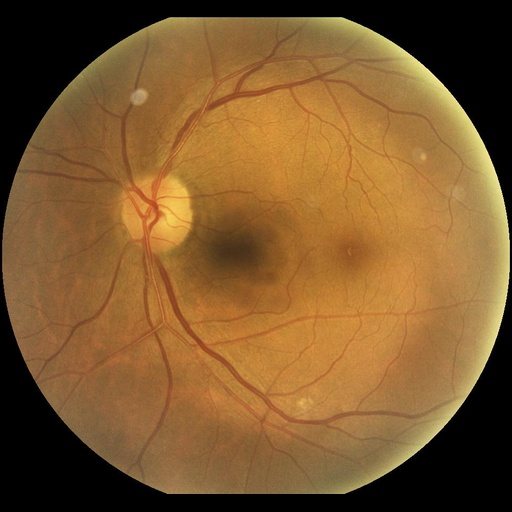

正常             : 0.12%
糖尿病视网膜病变       : 76.46%
青光眼            : 0.11%
白内障            : 0.05%
黄斑变性           : 0.09%
高血压视网膜病变       : 9.39%
近视             : 0.01%
其他             : 67.62%


In [21]:
# 预处理图片增加batch维度
def preprocess_image(image_path): 
    image = Image.open(image_path)

    transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
    ])
    
    image_tensor = transform(image).unsqueeze(0)
    return image, image_tensor


checkpoint_path = r'C:\Users\lenovo\Desktop\graduation_project\checkpoints\best_model_1.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])


model = model.to(device)
model.eval()

#简单预测图片
def predict_image(image_path, threshold=0.5):
    original_image,image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]
        
    predictions = (probabilities > threshold).astype(int)

    display(original_image)

    for i, (name, prob) in enumerate(zip(config['class_names'], probabilities)):
        print(f"{name:15}: {prob:.2%}")
    
    return probabilities, predictions


test_image_path = r'C:\Users\lenovo\Desktop\graduation_project\data\new\validation images\1024_left.jpg'
probs, preds = predict_image(test_image_path)




In [19]:
# 验证阶段

val_loss = 0  # 累计验证的损失
val_correct = 0  # 正确预测的数量
val_total = 0  # 总数

all_predicts = [] # 存储所有的预测结果
all_labels = [] # 存储所有的真实标签

inference_times = []

# writer = SummaryWriter('logss')

model.eval() # 开启验证模式
with torch.no_grad():   # 不计算梯度来节省内存加速运行
    
    for image, labels, img_name in val_loader:
        image = image.to(device)
        labels = labels.to(device)

        start_time = time.time() # 记录开始时间  
        
        # 前向传播
        outputs = model(image)
        
        inference_time = time.time()-start_time
        inference_times.append(inference_time)
        
        loss = criterion(outputs.logits, labels) # 计算损失
        probability = torch.sigmoid(outputs.logits) # sigmoid将概率转化到0-1之间
        predict = (probability >0.5).float() # 转化为0-1预测

        val_loss += loss.item() # 累计损失
        
        # 当预测值和真实值相同时，转化为bool值的张量
        # all(dim=1)将每一行的结果统计为一个（如一行都为true，则为true，若一行有一个false，则为false），然后返回n行个bool值
        # item()统计有几个true
        val_correct += (predict == labels).all(dim=1).sum().item()
        val_total += labels.size(0) # 计算损失总数
        
        all_predicts.append(predict.cpu().numpy()) # 预测结果存入
        all_labels.append(labels.cpu().numpy())   # 真实数据存入
        

    avg_val_loss = val_loss / len(val_loader) 
    avg_val_accuracy = val_correct / val_total

    all_predicts = np.vstack(all_predicts)
    all_labels = np.vstack(all_labels)

    print(all_predicts)
    print(all_labels)

    results = {}
    for i, disease in enumerate(config['class_names']): # 通过分类标签计算疾病
        precision = precision_score(all_labels[:, i], all_predicts[:, i])
        recall = recall_score(all_labels[:, i], all_predicts[:, i])

    print('准确率：',precision)
    print(recall)

    macro_f1 = f1_score(all_predicts, all_labels, average='macro', zero_division=0)   # 计算准确率
    micro_f1 = f1_score(all_predicts, all_labels, average='micro',zero_division=0)   # 计算召回率

    print(macro_f1)
    print(micro_f1)

    per_class_precision = precision_score(all_labels, all_predicts, average=None, zero_division=0) #计算各类的准确率
    per_class_recall = recall_score(all_labels, all_predicts, average=None, zero_division=0) # 计算各类的召回率
    per_class_f1 = f1_score(all_labels, all_predicts, average=None, zero_division=0) # 计算f1

    print('/n',per_class_precision)
    print(per_class_recall)
    print(per_class_f1)

    mean_time = np.mean(inference_times)
    sum_time = np.sum(inference_times)

    print(mean_time)
    print(sum_time)
    


    # writer.add_scalar('Loss/Validation', avg_val_loss, epoch)
    # writer.add_scalar('Accuracy/Validation', avg_val_accuracy, epoch)
    

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
准确率： 0.45081967213114754
0.37844036697247707
0.4771394149846788
0.47283126787416585
/n [0.41322314 0.56296296 0.39534884 0.71232877 0.58695652 0.6
 0.83636364 0.45081967]
[0.4784689  0.49781659 0.25757576 0.60465116 0.39705882 0.14516129
 0.6969697  0.37844037]
[0.44345898 0.52838934 0.31192661 0.65408805 0.47368421 0.23376623
 0.76033058 0.41147132]
0.00992490215735002
0.8733913898468018


In [1]:
# 找出验证集中所有罕见病样本
rare_disease_indices = []
rare_disease_name = '高血压视网膜病变'
disease_idx = config['class_names'].index(rare_disease_name)

for i in range(len(val_dataset)):
    _, labels, img_name = val_dataset[i]
    if labels[disease_idx] == 1:
        rare_disease_indices.append((i, img_name))

print(f"验证集中有 {len(rare_disease_indices)} 张 {rare_disease_name} 图片")

# 逐个测试
correct = 0
for idx, img_name in rare_disease_indices:
    img_path = os.path.join(val_dir, img_name)
    probs, preds = predict_image(img_path)
    if preds[disease_idx] == 1:
        correct += 1
        print(f"✅ {img_name}: 正确")
    else:
        print(f"❌ {img_name}: 错误，概率={probs[disease_idx]:.2%}")

print(f"罕见病识别准确率: {correct}/{len(rare_disease_indices)} = {correct/len(rare_disease_indices)*100:.1f}%")

NameError: name 'config' is not defined

In [22]:
# 对整个验证集进行评估
def evaluate_validation_set(model, val_loader, device, config):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels, img_names in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs.logits)
            preds = (probs > 0.5).float().cpu().numpy()
            
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # 计算每个类别的F1分数
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print("\n" + "="*60)
    print("验证集评估结果")
    print("="*60)
    
    for i, disease in enumerate(config['class_names']):
        f1 = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        precision = precision_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        recall = recall_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        
        print(f"\n{disease}:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1: {f1:.4f}")
    
    # 总体指标
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"\n总体:")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Weighted F1: {weighted_f1:.4f}")
    
    return all_preds, all_labels

# 运行评估
evaluate_validation_set(model, val_loader, device, config)


验证集评估结果

正常:
  Precision: 0.4132
  Recall: 0.4785
  F1: 0.4435

糖尿病视网膜病变:
  Precision: 0.5630
  Recall: 0.4978
  F1: 0.5284

青光眼:
  Precision: 0.3953
  Recall: 0.2576
  F1: 0.3119

白内障:
  Precision: 0.7123
  Recall: 0.6047
  F1: 0.6541

黄斑变性:
  Precision: 0.5870
  Recall: 0.3971
  F1: 0.4737

高血压视网膜病变:
  Precision: 0.6000
  Recall: 0.1452
  F1: 0.2338

近视:
  Precision: 0.8364
  Recall: 0.6970
  F1: 0.7603

其他:
  Precision: 0.4508
  Recall: 0.3784
  F1: 0.4115

总体:
  Macro F1: 0.4771
  Weighted F1: 0.4702


(array([[0., 1., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]], dtype=float32))

In [23]:
# 比较训练集和验证集的标签分布
def check_distribution(dataset, name):
    all_labels = []
    for i in range(len(dataset)):
        _, labels, _ = dataset[i]
        all_labels.append(labels.numpy())
    
    all_labels = np.vstack(all_labels)
    print(f"\n{name}分布:")
    for i, disease in enumerate(config['class_names']):
        pos_rate = all_labels[:, i].mean() * 100
        print(f"  {disease}: {pos_rate:.1f}%")

check_distribution(train_dataset, "训练集")
check_distribution(val_dataset, "验证集")


训练集分布:
  正常: 33.2%
  糖尿病视网膜病变: 32.1%
  青光眼: 6.5%
  白内障: 6.0%
  黄斑变性: 4.6%
  高血压视网膜病变: 2.6%
  近视: 5.0%
  其他: 27.2%

验证集分布:
  正常: 29.9%
  糖尿病视网膜病变: 32.7%
  青光眼: 4.7%
  白内障: 6.1%
  黄斑变性: 4.9%
  高血压视网膜病变: 4.4%
  近视: 4.7%
  其他: 31.1%


In [25]:
# ==================== 验证阶段 + 阈值优化 ====================

# 确认模型在eval模式
model.eval()

val_loss = 0
val_correct = 0
val_total = 0

# 存储数据
all_probs = []      # 存储预测概率（用于调阈值）
all_labels = []     # 存储真实标签
inference_times = []

with torch.no_grad():
    for images, labels, img_names in tqdm(val_loader, desc='验证中'):
        images = images.to(device)
        labels = labels.to(device)

        start_time = time.time()
        outputs = model(images)
        inference_time = time.time() - start_time
        inference_times.append(inference_time)
        
        loss = criterion(outputs.logits, labels)
        
        # 计算概率
        probs = torch.sigmoid(outputs.logits)
        preds_05 = (probs > 0.5).float()

        val_loss += loss.item()
        val_correct += (preds_05 == labels).all(dim=1).sum().item()
        val_total += labels.size(0)
        
        # 保存数据
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# 计算平均指标
avg_val_loss = val_loss / len(val_loader)
avg_val_accuracy = val_correct / val_total

# 合并数据
all_probs = np.vstack(all_probs)      # 形状: (1400, 8)
all_labels = np.vstack(all_labels)    # 形状: (1400, 8)

print(f"\n验证集大小: {len(all_labels)} 张图片")
print(f"预测概率形状: {all_probs.shape}")
print(f"真实标签形状: {all_labels.shape}")
print(f"验证损失: {avg_val_loss:.4f}")
print(f"严格准确率(8标签全对): {avg_val_accuracy:.4f}")

验证中:   0%|          | 0/88 [00:00<?, ?it/s]


验证集大小: 1400 张图片
预测概率形状: (1400, 8)
真实标签形状: (1400, 8)
验证损失: 0.5890
严格准确率(8标签全对): 0.3336


In [27]:
# ==================== 原始结果 (阈值=0.5) ====================
print("\n" + "="*60)
print("原始结果 (阈值=0.5)")
print("="*60)

all_preds_05 = (all_probs > 0.5).astype(int)

for i, disease in enumerate(config['class_names']):
    precision = precision_score(all_labels[:, i], all_preds_05[:, i], zero_division=0)
    recall = recall_score(all_labels[:, i], all_preds_05[:, i], zero_division=0)
    f1 = f1_score(all_labels[:, i], all_preds_05[:, i], zero_division=0)
    
    print(f"\n{disease}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")

macro_f1_05 = f1_score(all_labels, all_preds_05, average='macro', zero_division=0)
micro_f1_05 = f1_score(all_labels, all_preds_05, average='micro', zero_division=0)

print(f"\n总体:")
print(f"  Macro F1: {macro_f1_05:.4f}")
print(f"  Micro F1: {micro_f1_05:.4f}")


原始结果 (阈值=0.5)

正常:
  Precision: 0.4132
  Recall: 0.4785
  F1: 0.4435

糖尿病视网膜病变:
  Precision: 0.5630
  Recall: 0.4978
  F1: 0.5284

青光眼:
  Precision: 0.3953
  Recall: 0.2576
  F1: 0.3119

白内障:
  Precision: 0.7123
  Recall: 0.6047
  F1: 0.6541

黄斑变性:
  Precision: 0.5870
  Recall: 0.3971
  F1: 0.4737

高血压视网膜病变:
  Precision: 0.6000
  Recall: 0.1452
  F1: 0.2338

近视:
  Precision: 0.8364
  Recall: 0.6970
  F1: 0.7603

其他:
  Precision: 0.4508
  Recall: 0.3784
  F1: 0.4115

总体:
  Macro F1: 0.4771
  Micro F1: 0.4728


In [28]:
# ==================== 阈值优化 ====================
print("\n" + "="*60)
print("阈值优化")
print("="*60)

best_thresholds = {}
best_f1_scores = {}

for i, disease in enumerate(config['class_names']):
    best_f1 = 0
    best_th = 0.5
    
    y_true = all_labels[:, i]
    y_score = all_probs[:, i]
    f1_05 = f1_score(y_true, (y_score > 0.5).astype(int), zero_division=0)
    
    # 尝试不同的阈值
    for th in np.arange(0.1, 0.9, 0.02):
        y_pred = (y_score > th).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
    
    best_thresholds[disease] = best_th
    best_f1_scores[disease] = best_f1
    
    print(f"{disease}: 最佳阈值={best_th:.2f}, F1从 {f1_05:.4f} → {best_f1:.4f}")

print(f"\n最佳阈值字典:")
print(best_thresholds)


阈值优化
正常: 最佳阈值=0.10, F1从 0.4435 → 0.5066
糖尿病视网膜病变: 最佳阈值=0.10, F1从 0.5284 → 0.5550
青光眼: 最佳阈值=0.26, F1从 0.3119 → 0.3500
白内障: 最佳阈值=0.70, F1从 0.6541 → 0.6755
黄斑变性: 最佳阈值=0.38, F1从 0.4737 → 0.4746
高血压视网膜病变: 最佳阈值=0.14, F1从 0.2338 → 0.3864
近视: 最佳阈值=0.16, F1从 0.7603 → 0.7907
其他: 最佳阈值=0.16, F1从 0.4115 → 0.4557

最佳阈值字典:
{'正常': np.float64(0.1), '糖尿病视网膜病变': np.float64(0.1), '青光眼': np.float64(0.26), '白内障': np.float64(0.7000000000000001), '黄斑变性': np.float64(0.38), '高血压视网膜病变': np.float64(0.14), '近视': np.float64(0.16000000000000003), '其他': np.float64(0.16000000000000003)}


In [29]:
# ==================== 用最佳阈值重新评估 ====================
print("\n" + "="*60)
print("用最佳阈值重新评估")
print("="*60)

# 用每个疾病的最佳阈值重新生成预测
y_pred_optimized = np.zeros_like(all_probs)
threshold_list = list(best_thresholds.values())

for i, disease in enumerate(config['class_names']):
    th = best_thresholds[disease]
    y_pred_optimized[:, i] = (all_probs[:, i] > th).astype(int)

# 计算优化后的指标
for i, disease in enumerate(config['class_names']):
    precision = precision_score(all_labels[:, i], y_pred_optimized[:, i], zero_division=0)
    recall = recall_score(all_labels[:, i], y_pred_optimized[:, i], zero_division=0)
    f1 = f1_score(all_labels[:, i], y_pred_optimized[:, i], zero_division=0)
    
    print(f"\n{disease}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f} (阈值={best_thresholds[disease]:.2f})")

# 优化后的总体指标
macro_f1_opt = f1_score(all_labels, y_pred_optimized, average='macro', zero_division=0)
micro_f1_opt = f1_score(all_labels, y_pred_optimized, average='micro', zero_division=0)

print(f"\n总体:")
print(f"  Macro F1: {macro_f1_05:.4f} → {macro_f1_opt:.4f} (提升: {(macro_f1_opt-macro_f1_05)/macro_f1_05*100:+.1f}%)")

# 推理时间
mean_time = np.mean(inference_times) * 1000
sum_time = np.sum(inference_times)

print(f"\n推理时间:")
print(f"  平均每张图片: {mean_time:.2f} ms")
print(f"  总推理时间: {sum_time:.2f} 秒")


用最佳阈值重新评估

正常:
  Precision: 0.4177
  Recall: 0.6435
  F1: 0.5066 (阈值=0.10)

糖尿病视网膜病变:
  Precision: 0.5009
  Recall: 0.6223
  F1: 0.5550 (阈值=0.10)

青光眼:
  Precision: 0.3889
  Recall: 0.3182
  F1: 0.3500 (阈值=0.26)

白内障:
  Precision: 0.7846
  Recall: 0.5930
  F1: 0.6755 (阈值=0.70)

黄斑变性:
  Precision: 0.5600
  Recall: 0.4118
  F1: 0.4746 (阈值=0.38)

高血压视网膜病变:
  Precision: 0.6538
  Recall: 0.2742
  F1: 0.3864 (阈值=0.14)

近视:
  Precision: 0.8095
  Recall: 0.7727
  F1: 0.7907 (阈值=0.16)

其他:
  Precision: 0.4219
  Recall: 0.4954
  F1: 0.4557 (阈值=0.16)

总体:
  Macro F1: 0.4771 → 0.5243 (提升: +9.9%)

推理时间:
  平均每张图片: 10.77 ms
  总推理时间: 0.95 秒


In [30]:
# ==================== 用最佳阈值的预测函数 ====================

def preprocess_image(image_path):
    """预处理图片"""
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    image_tensor = transform(image).unsqueeze(0)
    return image, image_tensor

def predict_with_best_threshold(image_path, thresholds=None):
    """用最佳阈值预测单张图片"""
    if thresholds is None:
        thresholds = best_thresholds
    
    original_image, image_tensor = preprocess_image(image_path)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    
    # 用每个疾病的最佳阈值
    predictions = np.zeros(8)
    threshold_list = [thresholds[d] for d in config['class_names']]
    
    for i in range(8):
        predictions[i] = 1 if probabilities[i] > threshold_list[i] else 0

    # 显示图片
    plt.figure(figsize=(8, 8))
    plt.imshow(original_image)
    plt.title(f"测试图片: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

    # 打印结果
    print("\n" + "="*60)
    print("预测结果 (用最佳阈值)")
    print("="*60)
    
    detected = []
    for i, (name, prob) in enumerate(zip(config['class_names'], probabilities)):
        th = threshold_list[i]
        marker = "✓" if predictions[i] == 1 else "✗"
        print(f"{marker} {name:15}: {prob:.2%} (阈值={th:.2f})")
        if predictions[i] == 1:
            detected.append(name)
    
    print("\n" + "="*60)
    if detected:
        print(f"检测到的疾病: {', '.join(detected)}")
    else:
        print("检测结果: 正常")
    print("="*60)
    
    return probabilities, predictions

# 测试一张图片
test_image_path = r'C:\Users\lenovo\Desktop\graduation_project\data\new\Validation Images\818_left.jpg'
if os.path.exists(test_image_path):
    probs, preds = predict_with_best_threshold(test_image_path)
else:
    print(f"文件不存在: {test_image_path}")

NameError: name 'plt' is not defined